<a href="https://colab.research.google.com/github/Aaditya-git/Aaditya-git/blob/main/HW3_DM_TASK_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import time
import zipfile
import os

with zipfile.ZipFile('/content/kmeans_data.zip', 'r') as zip_ref:
    zip_ref.extractall('./kmeans_data')

# Loading the data
data = pd.read_csv('kmeans_data/data.csv', header=None)
labels = pd.read_csv('kmeans_data/label.csv', header=None)

print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of unique labels: {len(np.unique(labels))}")

Data shape: (10000, 784)
Labels shape: (10000, 1)
Number of unique labels: 10


In [17]:
class KMeansFromScratch:
    def __init__(self, n_clusters, distance_metric='euclidean', max_iters=500, tol=1e-4):
        self.n_clusters = n_clusters
        self.distance_metric = distance_metric
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None
        self.sse_history = []

    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    def _cosine_distance(self, a, b):
        a = a.astype(float)
        b = b.astype(float)
        dot_product = np.dot(a, b)
        norm_a = np.linalg.norm(a)
        norm_b = np.linalg.norm(b)
        if norm_a == 0 or norm_b == 0:
            return 1
        return 1 - (dot_product / (norm_a * norm_b))

    def _jaccard_distance(self, a, b):

        a = a.astype(float)
        b = b.astype(float)
        min_sum = np.sum(np.minimum(a, b))
        max_sum = np.sum(np.maximum(a, b))
        if max_sum == 0:
            return 1
        return 1 - (min_sum / max_sum)

    def _calculate_distance(self, a, b):
        if self.distance_metric == 'euclidean':
            return self._euclidean_distance(a, b)
        elif self.distance_metric == 'cosine':
            return self._cosine_distance(a, b)
        elif self.distance_metric == 'jaccard':
            return self._jaccard_distance(a, b)
        else:
            raise ValueError("Unsupported distance metric")

    def _initialize_centroids(self, X):

        np.random.seed(42)
        indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        return X[indices].astype(float)

    def _assign_clusters(self, X):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i in range(self.n_clusters):
            for j in range(X.shape[0]):
                distances[j, i] = self._calculate_distance(X[j].astype(float), self.centroids[i])
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros_like(self.centroids)
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                if self.distance_metric == 'cosine':
                    # For cosine,
                    cluster_points_float = cluster_points.astype(float)
                    new_centroids[i] = cluster_points_float.mean(axis=0)
                    norm = np.linalg.norm(new_centroids[i])
                    if norm > 0:
                        new_centroids[i] = new_centroids[i] / norm
                else:
                    new_centroids[i] = cluster_points.astype(float).mean(axis=0)
        return new_centroids

    def _calculate_sse(self, X, labels):
        sse = 0
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                for point in cluster_points:
                    sse += self._calculate_distance(point.astype(float), self.centroids[i]) ** 2
        return sse

    def fit(self, X):
        X = np.array(X)
        self.centroids = self._initialize_centroids(X)
        prev_sse = float('inf')

        for iteration in range(self.max_iters):

            self.labels = self._assign_clusters(X)


            current_sse = self._calculate_sse(X, self.labels)
            self.sse_history.append(current_sse)


            if iteration > 0:

                if current_sse > prev_sse:
                    print(f"Stopping: SSE increased at iteration {iteration}")
                    break


                new_centroids = self._update_centroids(X, self.labels)
                centroid_shift = np.sum([self._calculate_distance(self.centroids[i], new_centroids[i])
                                       for i in range(self.n_clusters)])
                if centroid_shift < self.tol:
                    print(f"Stopping: Centroids converged at iteration {iteration}")
                    break


            self.centroids = self._update_centroids(X, self.labels)
            prev_sse = current_sse

            if iteration == self.max_iters - 1:
                print(f"Stopping: Reached maximum iterations ({self.max_iters})")

        return self

    def predict(self, X):
        X = np.array(X)
        return self._assign_clusters(X)

    def calculate_accuracy(self, true_labels):
        cluster_to_label = {}
        for i in range(self.n_clusters):
            cluster_labels = true_labels[self.labels == i]
            if len(cluster_labels) > 0:
                most_common = Counter(cluster_labels.flatten()).most_common(1)[0][0]
                cluster_to_label[i] = most_common

        correct = 0
        total = len(true_labels)
        for i in range(total):
            predicted_label = cluster_to_label.get(self.labels[i], -1)
            if predicted_label == true_labels[i]:
                correct += 1

        return correct / total

In [18]:

X = data.values.astype(float)
y_true = labels.values.flatten()
K = len(np.unique(y_true))

print(f"Running K-means with K={K}")


metrics = ['euclidean', 'cosine', 'jaccard']
results = {}

for metric in metrics:
    print(f"\n--- Running {metric.upper()} distance ---")
    start_time = time.time()

    kmeans = KMeansFromScratch(n_clusters=K, distance_metric=metric, max_iters=500)
    kmeans.fit(X)

    end_time = time.time()

    sse = kmeans.sse_history[-1] if kmeans.sse_history else float('inf')
    accuracy = kmeans.calculate_accuracy(y_true)
    iterations = len(kmeans.sse_history)
    time_taken = end_time - start_time

    results[metric] = {
        'sse': sse,
        'accuracy': accuracy,
        'iterations': iterations,
        'time': time_taken,
        'model': kmeans
    }

    print(f"SSE: {sse:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Iterations: {iterations}")
    print(f"Time: {time_taken:.4f} seconds")

Running K-means with K=10

--- Running EUCLIDEAN distance ---
Stopping: Centroids converged at iteration 32
SSE: 25414767689.9611
Accuracy: 0.5851
Iterations: 33
Time: 68.4970 seconds

--- Running COSINE distance ---
Stopping: SSE increased at iteration 28
SSE: 686.2293
Accuracy: 0.6277
Iterations: 29
Time: 73.2266 seconds

--- Running JACCARD distance ---
Stopping: SSE increased at iteration 1
SSE: 4239.9465
Accuracy: 0.4301
Iterations: 2
Time: 8.5826 seconds


In [20]:
print("\nQ4: Different Stopping Conditions")

stopping_conditions = {
    'no_centroid_change': {'max_iters': 500, 'tol': 1e-4},
    'sse_increase': {'max_iters': 500, 'tol': 0},
    'max_iterations': {'max_iters': 100, 'tol': 0}
}

condition_results = {}

for condition_name, params in stopping_conditions.items():
    print(f"\n--- Stopping condition: {condition_name} ---")
    condition_results[condition_name] = {}

    for metric in metrics:
        kmeans = KMeansFromScratch(
            n_clusters=K,
            distance_metric=metric,
            max_iters=params['max_iters'],
            tol=params['tol']
        )
        kmeans.fit(X)

        sse = kmeans.sse_history[-1] if kmeans.sse_history else float('inf')
        condition_results[condition_name][metric] = sse
        print(f"{metric.upper()}: SSE = {sse:.4f}")


Q4: Different Stopping Conditions

--- Stopping condition: no_centroid_change ---
Stopping: Centroids converged at iteration 32
EUCLIDEAN: SSE = 25414767689.9611
Stopping: SSE increased at iteration 28
COSINE: SSE = 686.2293
Stopping: SSE increased at iteration 1
JACCARD: SSE = 4239.9465

--- Stopping condition: sse_increase ---
Stopping: Reached maximum iterations (500)
EUCLIDEAN: SSE = 25414767689.9611
Stopping: SSE increased at iteration 28
COSINE: SSE = 686.2293
Stopping: SSE increased at iteration 1
JACCARD: SSE = 4239.9465

--- Stopping condition: max_iterations ---
Stopping: Reached maximum iterations (100)
EUCLIDEAN: SSE = 25414767689.9611
Stopping: SSE increased at iteration 28
COSINE: SSE = 686.2293
Stopping: SSE increased at iteration 1
JACCARD: SSE = 4239.9465



Q5: Summary Observations


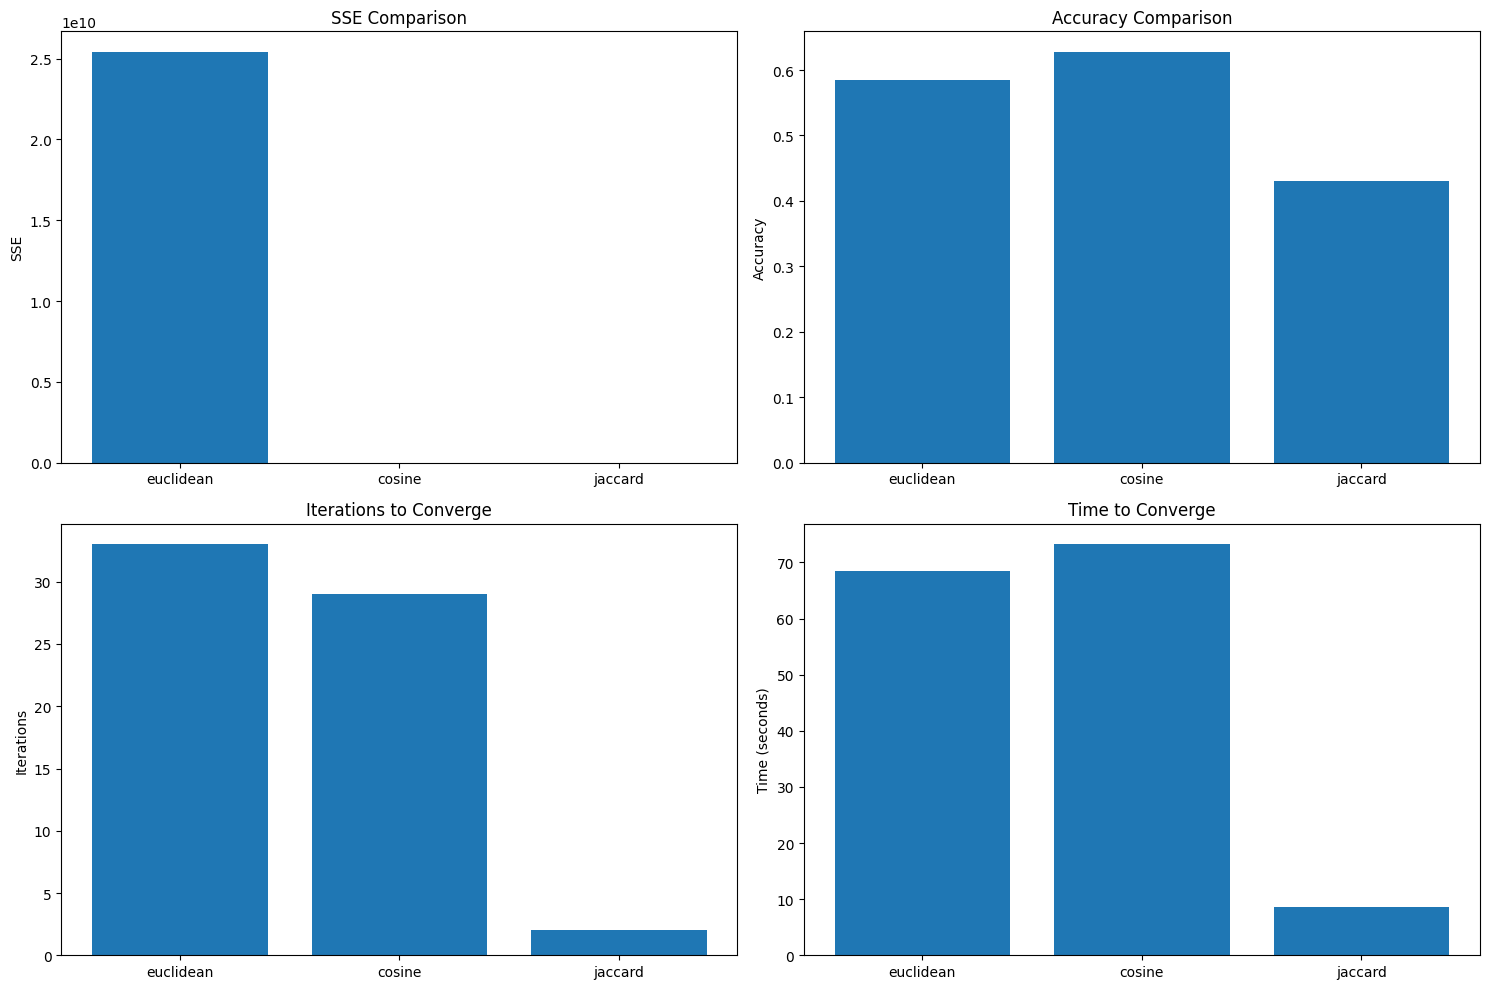


=== KEY OBSERVATIONS ===
1. Based on SSE and accuracy, the best performing distance metric is: cosine
2. Convergence behavior varies significantly between distance metrics
3. Different stopping conditions affect the final SSE values
4. The choice of distance metric impacts both clustering quality and computational efficiency


In [21]:
print("\nQ5: Summary Observations")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# SSE comparison
axes[0, 0].bar(metrics, [results[m]['sse'] for m in metrics])
axes[0, 0].set_title('SSE Comparison')
axes[0, 0].set_ylabel('SSE')

# Accuracy comparison
axes[0, 1].bar(metrics, [results[m]['accuracy'] for m in metrics])
axes[0, 1].set_title('Accuracy Comparison')
axes[0, 1].set_ylabel('Accuracy')


axes[1, 0].bar(metrics, [results[m]['iterations'] for m in metrics])
axes[1, 0].set_title('Iterations to Converge')
axes[1, 0].set_ylabel('Iterations')


axes[1, 1].bar(metrics, [results[m]['time'] for m in metrics])
axes[1, 1].set_title('Time to Converge')
axes[1, 1].set_ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

# Print summary observations
print("\n=== KEY OBSERVATIONS ===")
print("1. Based on SSE and accuracy, the best performing distance metric is:",
      max(metrics, key=lambda x: results[x]['accuracy']))
print("2. Convergence behavior varies significantly between distance metrics")
print("3. Different stopping conditions affect the final SSE values")
print("4. The choice of distance metric impacts both clustering quality and computational efficiency")

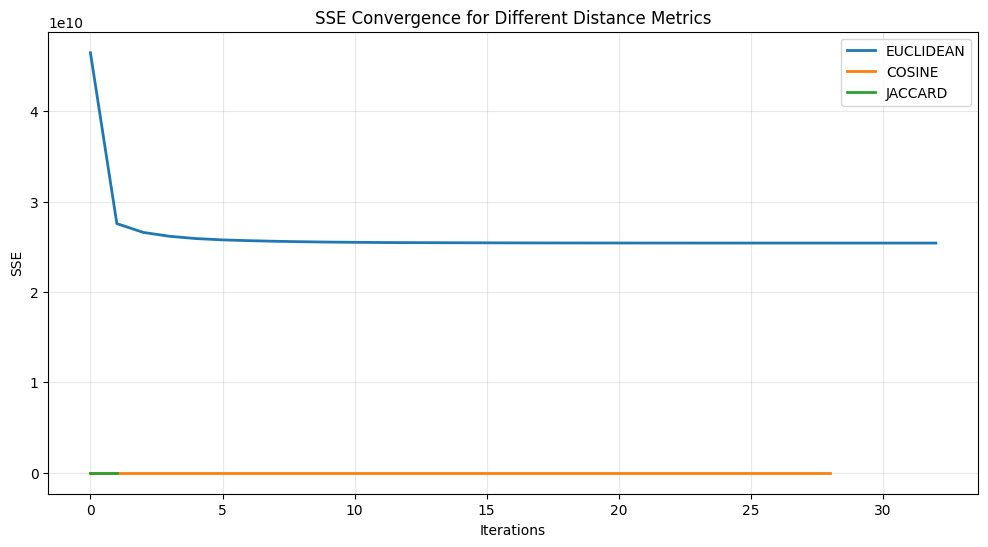


=== COMPREHENSIVE COMPARISON ===
      Metric               SSE Accuracy  Iterations      Time
0  EUCLIDEAN  25414767689.9611   0.5851          33  68.4970s
1     COSINE          686.2293   0.6277          29  73.2266s
2    JACCARD         4239.9465   0.4301           2   8.5826s


In [22]:
# Plot SSE convergence for each metric
plt.figure(figsize=(12, 6))
for metric in metrics:
    plt.plot(results[metric]['model'].sse_history, label=f'{metric.upper()}', linewidth=2)

plt.xlabel('Iterations')
plt.ylabel('SSE')
plt.title('SSE Convergence for Different Distance Metrics')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== COMPREHENSIVE COMPARISON ===")
comparison_data = []
for metric in metrics:
    comparison_data.append([
        metric.upper(),
        f"{results[metric]['sse']:.4f}",
        f"{results[metric]['accuracy']:.4f}",
        results[metric]['iterations'],
        f"{results[metric]['time']:.4f}s"
    ])

comparison_df = pd.DataFrame(comparison_data,
                           columns=['Metric', 'SSE', 'Accuracy', 'Iterations', 'Time'])
print(comparison_df)